In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(
    str(project_root)
)

In [2]:
import pandas as pd

from src.visualization.eda import HealthcareEDA

DATA_PATH = project_root / "data/processed/clean_data.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(280985, 39)


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,...,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
1,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
2,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
3,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
4,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 280985 entries, 0 to 280984
Data columns (total 39 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   composite_key         280985 non-null  str    
 1   age_level             280985 non-null  str    
 2   gender                280985 non-null  str    
 3   bmi_level             280985 non-null  str    
 4   smoking               280985 non-null  str    
 5   diabetes              280985 non-null  str    
 6   age                   280985 non-null  int64  
 7   age_normalized        280985 non-null  float64
 8   bmi                   280985 non-null  float64
 9   hypertension          280985 non-null  float64
 10  heart_disease         280985 non-null  float64
 11  HbA1c_level           280985 non-null  float64
 12  glucose               280985 non-null  float64
 13  cholesterol           280985 non-null  float64
 14  sleep_hours           280985 non-null  float64
 15  triglycerid

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,280985.0,49.665865,21.682350,2.000000,32.000000,50.000000,67.000000,89.000000
age_normalized,280985.0,0.547883,0.249222,0.000000,0.344827,0.551724,0.747126,1.000000
bmi,280985.0,27.490663,7.040373,10.010000,22.100000,27.320000,32.700000,95.690000
hypertension,280985.0,0.128218,0.187346,0.000000,0.000000,0.071429,0.217063,1.000000
heart_disease,280985.0,0.073390,0.138243,0.000000,0.000000,0.007299,0.115053,1.000000
HbA1c_level,280985.0,5.947475,0.954072,3.500000,5.384805,5.800000,6.865766,9.000000
glucose,280985.0,135.258646,38.477865,70.000000,100.000000,138.000000,160.000000,300.000000
cholesterol,280985.0,224.045525,35.525530,150.000000,202.000000,225.000000,243.000000,300.000000
sleep_hours,280985.0,6.954652,1.426412,4.000000,6.200000,6.975185,7.700000,10.000000
triglycerides,280985.0,178.995744,67.336085,50.000000,129.000000,179.000000,242.000000,400.000000


In [5]:
df.isnull().sum().sort_values(
    ascending=False
)

composite_key           0
age_level               0
gender                  0
bmi_level               0
smoking                 0
diabetes                0
age                     0
age_normalized          0
bmi                     0
hypertension            0
heart_disease           0
HbA1c_level             0
glucose                 0
cholesterol             0
sleep_hours             0
triglycerides           0
physical_activity       0
family_history          0
stress_level            0
low_hdl_cholesterol     0
high_ldl_cholesterol    0
blood_pressure          0
high_blood_pressure     0
sugar_consumption       0
crp_level               0
homocysteine_level      0
systolic_bp             0
diastolic_bp            0
alcohol_intake          0
salt_intake             0
heart_rate              0
hdl                     0
ldl                     0
education_level         0
employment_status       0
source_dataset          0
disease_flags           0
sublabel                0
label       

In [6]:
print(
    df["label"]
    .value_counts(dropna=False)
)

print(
    df["label"]
    .value_counts(
        normalize=True,
        dropna=False
    ) * 100
)

label
Abnormal    174101
Normal      106884
Name: count, dtype: int64
label
Abnormal    61.960959
Normal      38.039041
Name: proportion, dtype: float64


In [7]:
df["label"].unique()

<ArrowStringArray>
['Normal', 'Abnormal']
Length: 2, dtype: str

In [8]:
df["sublabel"].value_counts(
    dropna=False
)

sublabel
N           106884
HY           69806
DI_HY        66473
DI           31918
HT            2595
DI_HT         1398
HT_HY         1066
DI_HT_HY       845
Name: count, dtype: int64

In [9]:
pd.crosstab(
    df["label"],
    df["sublabel"]
)

sublabel,DI,DI_HT,DI_HT_HY,DI_HY,HT,HT_HY,HY,N
label,,,,,,,,
Abnormal,31918,1398,845,66473,2595,1066,69806,0
Normal,0,0,0,0,0,0,0,106884


In [10]:
df["disease_flags"].value_counts(
    dropna=False
).head(20)

disease_flags
0,0,0    106884
0,0,1     69806
1,0,1     66473
1,0,0     31918
0,1,0      2595
1,1,0      1398
0,1,1      1066
1,1,1       845
Name: count, dtype: int64

In [11]:
pd.crosstab(
    df["disease_flags"],
    df["label"]
)

label,Abnormal,Normal
disease_flags,,
"0,0,0",0,106884
"0,0,1",69806,0
"0,1,0",2595,0
"0,1,1",1066,0
"1,0,0",31918,0
"1,0,1",66473,0
"1,1,0",1398,0
"1,1,1",845,0


DATASET SUMMARY
Shape: (280985, 39)

Data Types:
composite_key               str
age_level                   str
gender                      str
bmi_level                   str
smoking                     str
diabetes                    str
age                       int64
age_normalized          float64
bmi                     float64
hypertension            float64
heart_disease           float64
HbA1c_level             float64
glucose                 float64
cholesterol             float64
sleep_hours             float64
triglycerides           float64
physical_activity           str
family_history              str
stress_level                str
low_hdl_cholesterol         str
high_ldl_cholesterol        str
blood_pressure          float64
high_blood_pressure         str
sugar_consumption           str
crp_level               float64
homocysteine_level      float64
systolic_bp             float64
diastolic_bp            float64
alcohol_intake          float64
salt_intake            

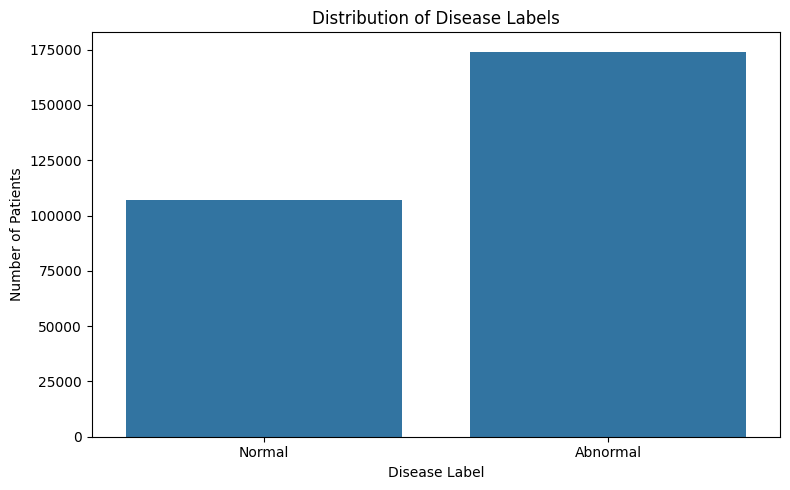

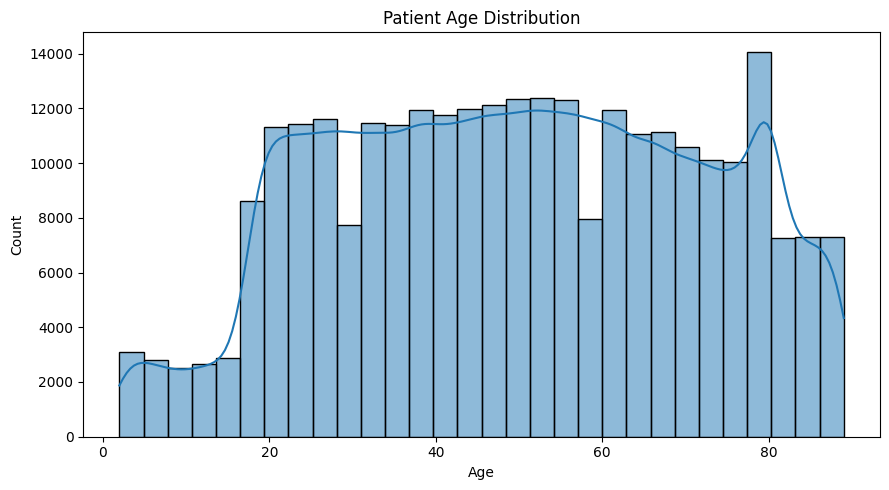

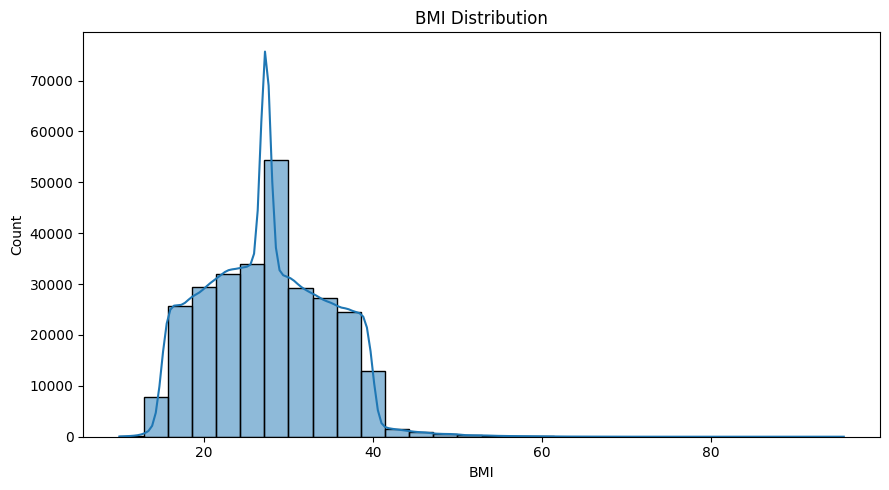

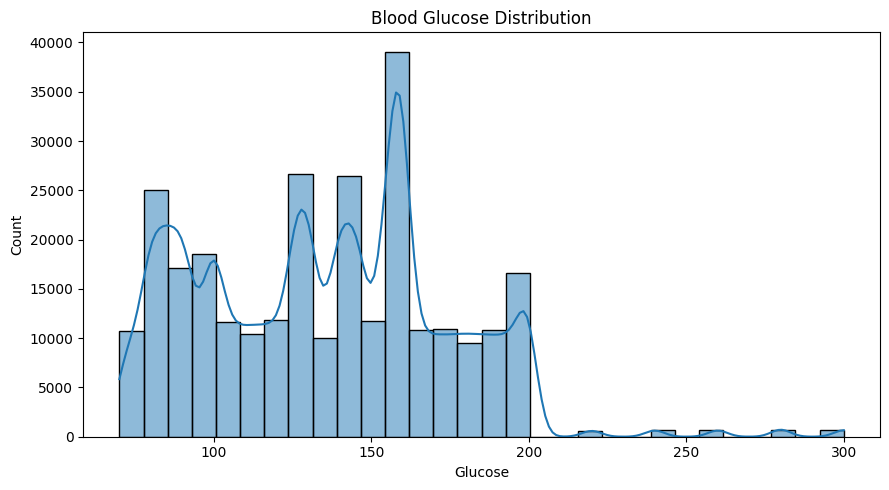

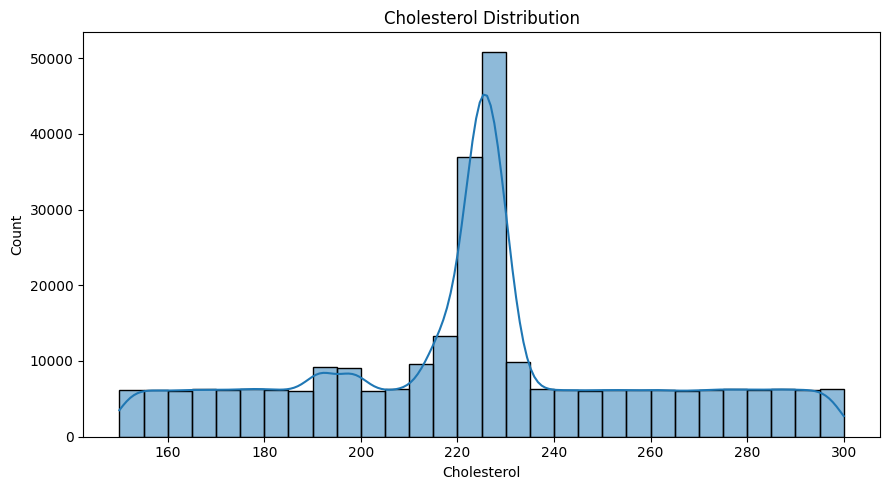

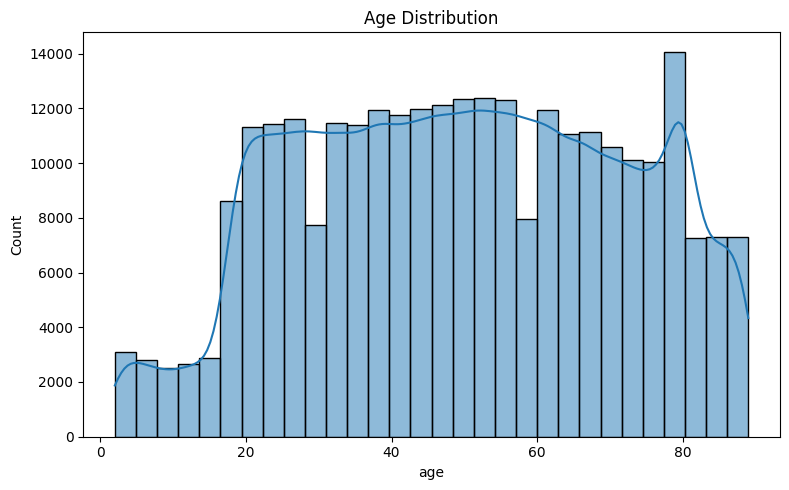

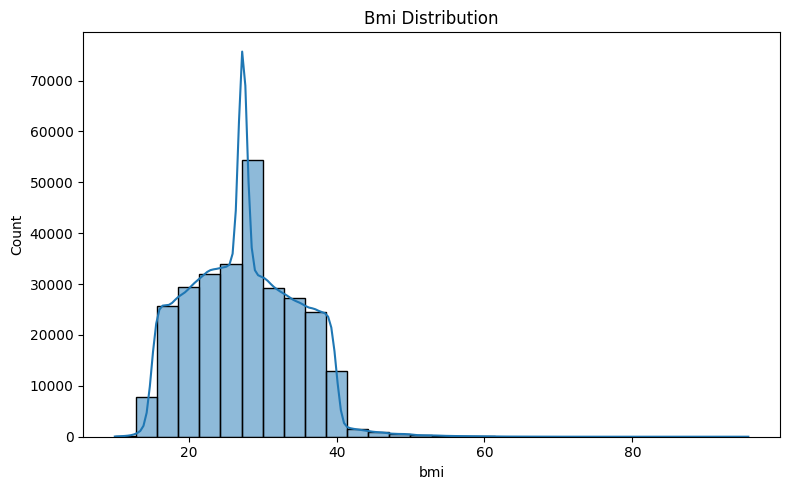

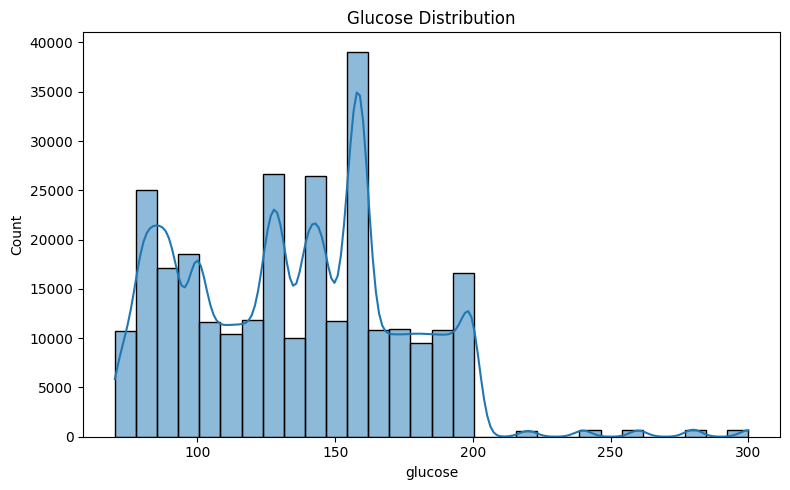

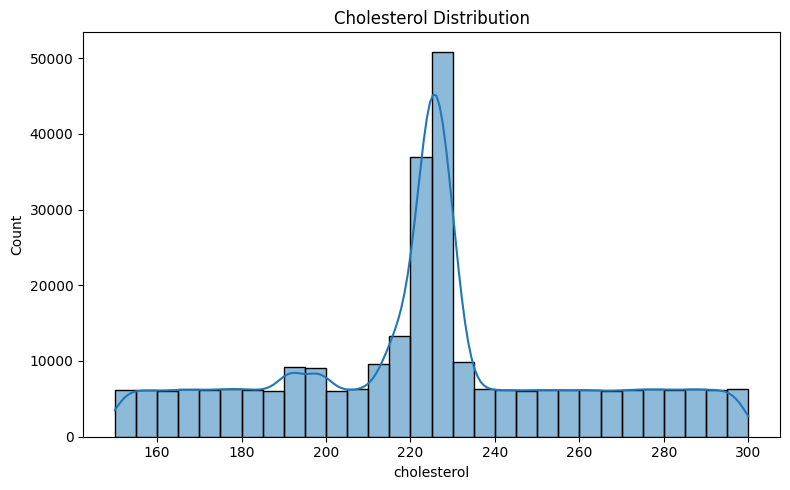

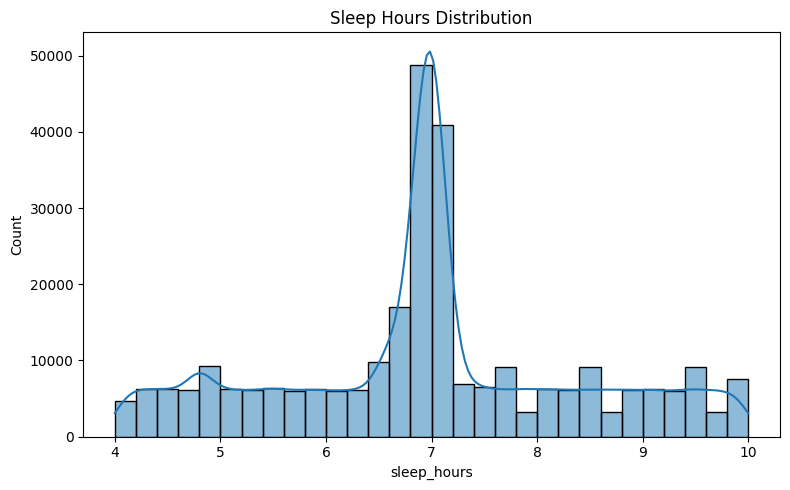

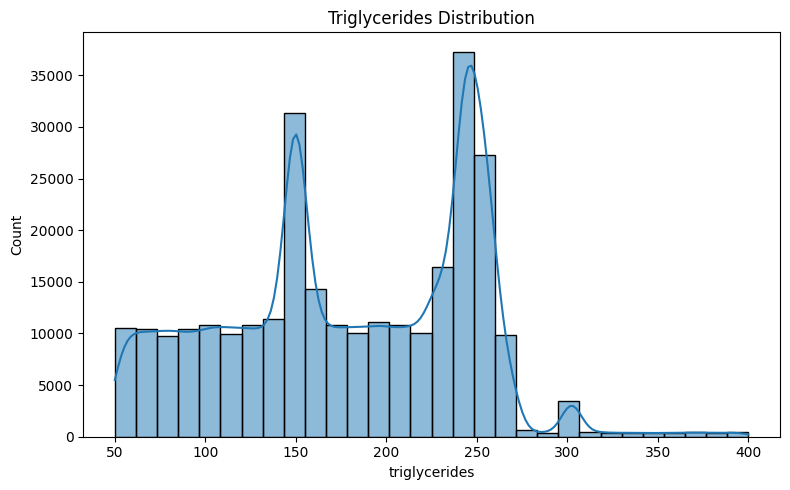

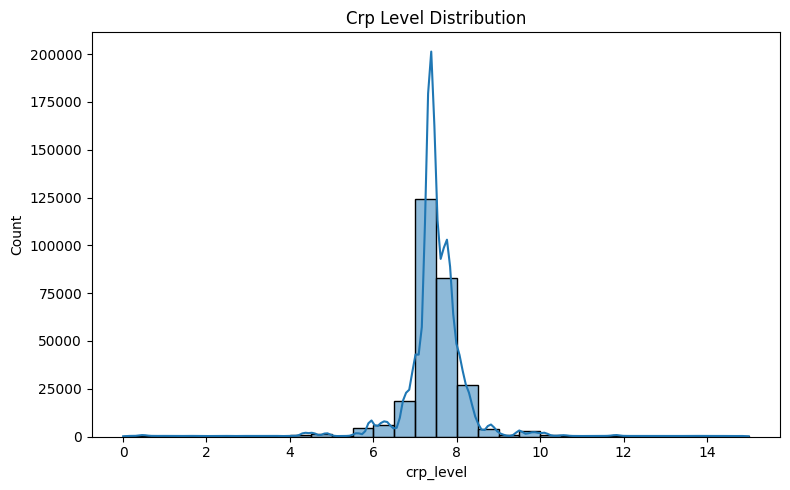

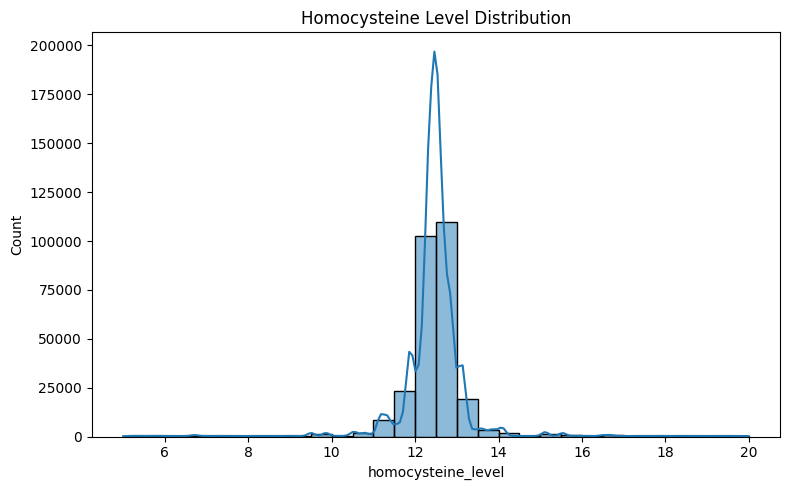

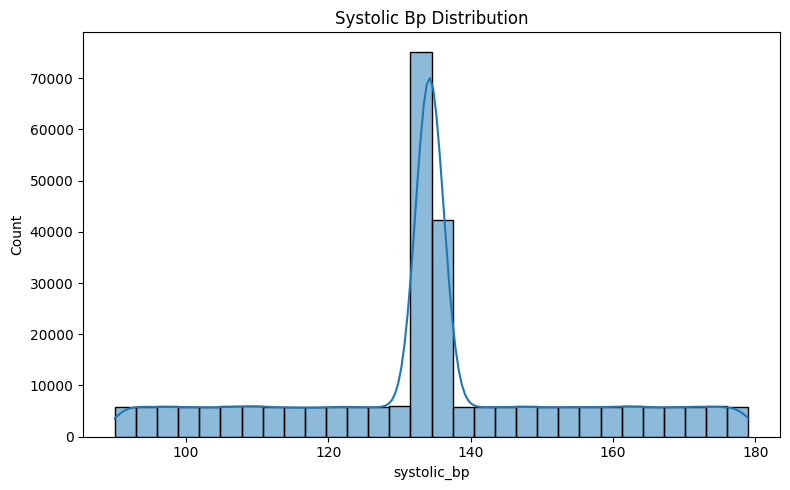

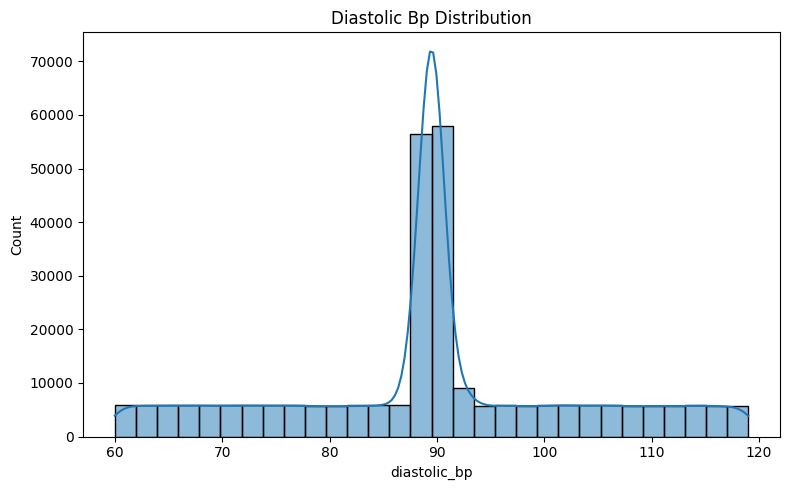

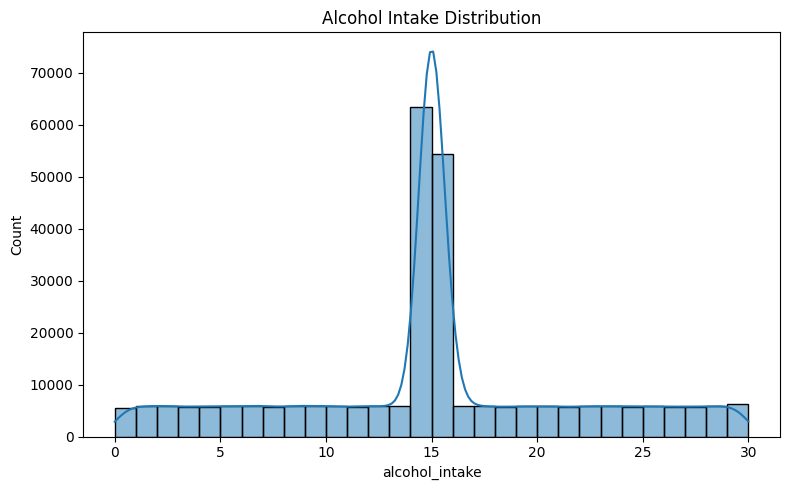

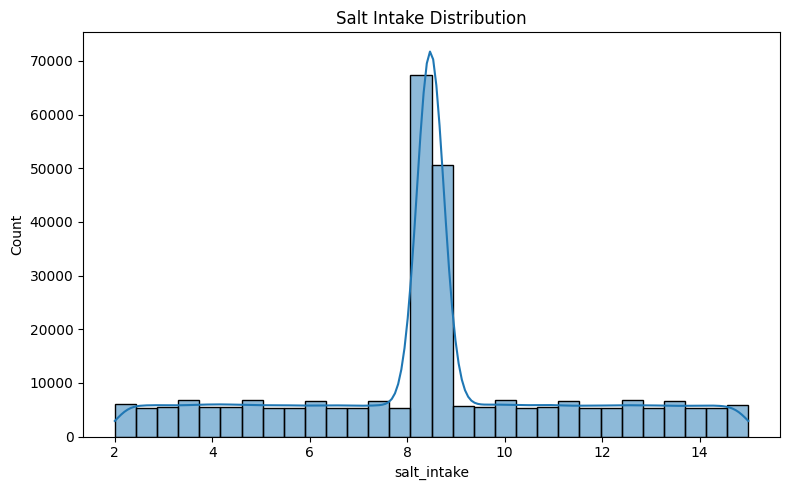

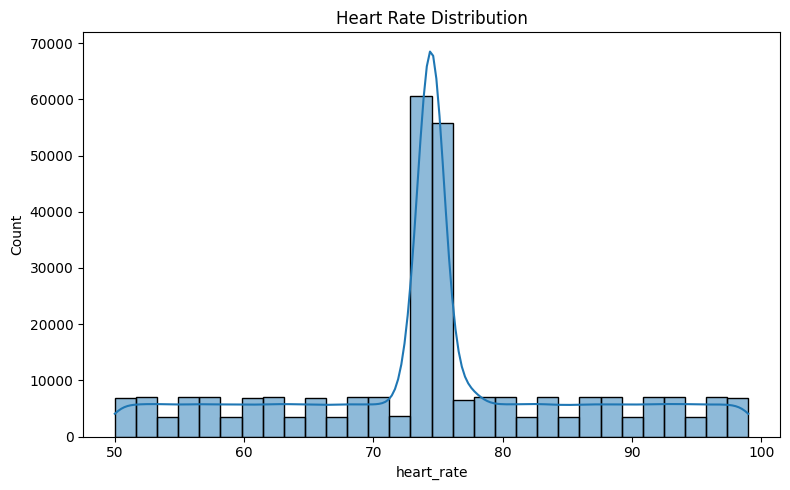

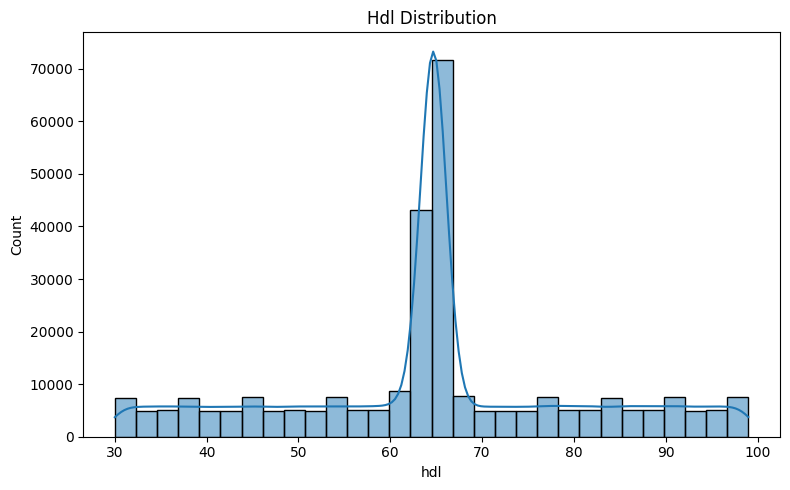

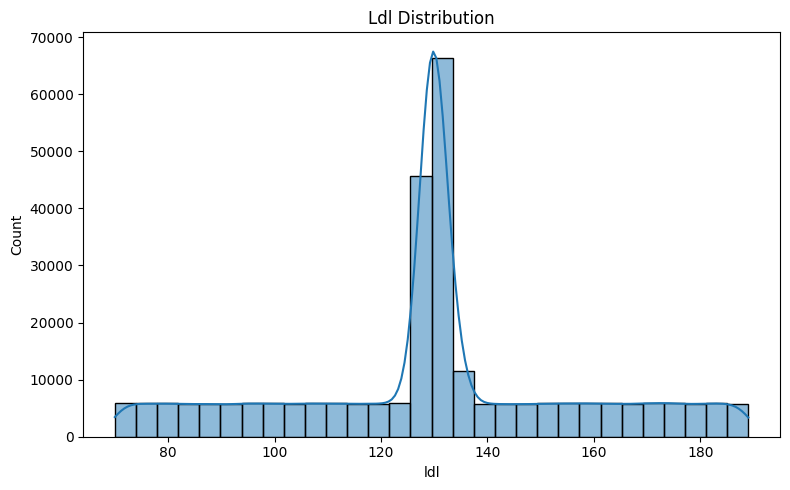

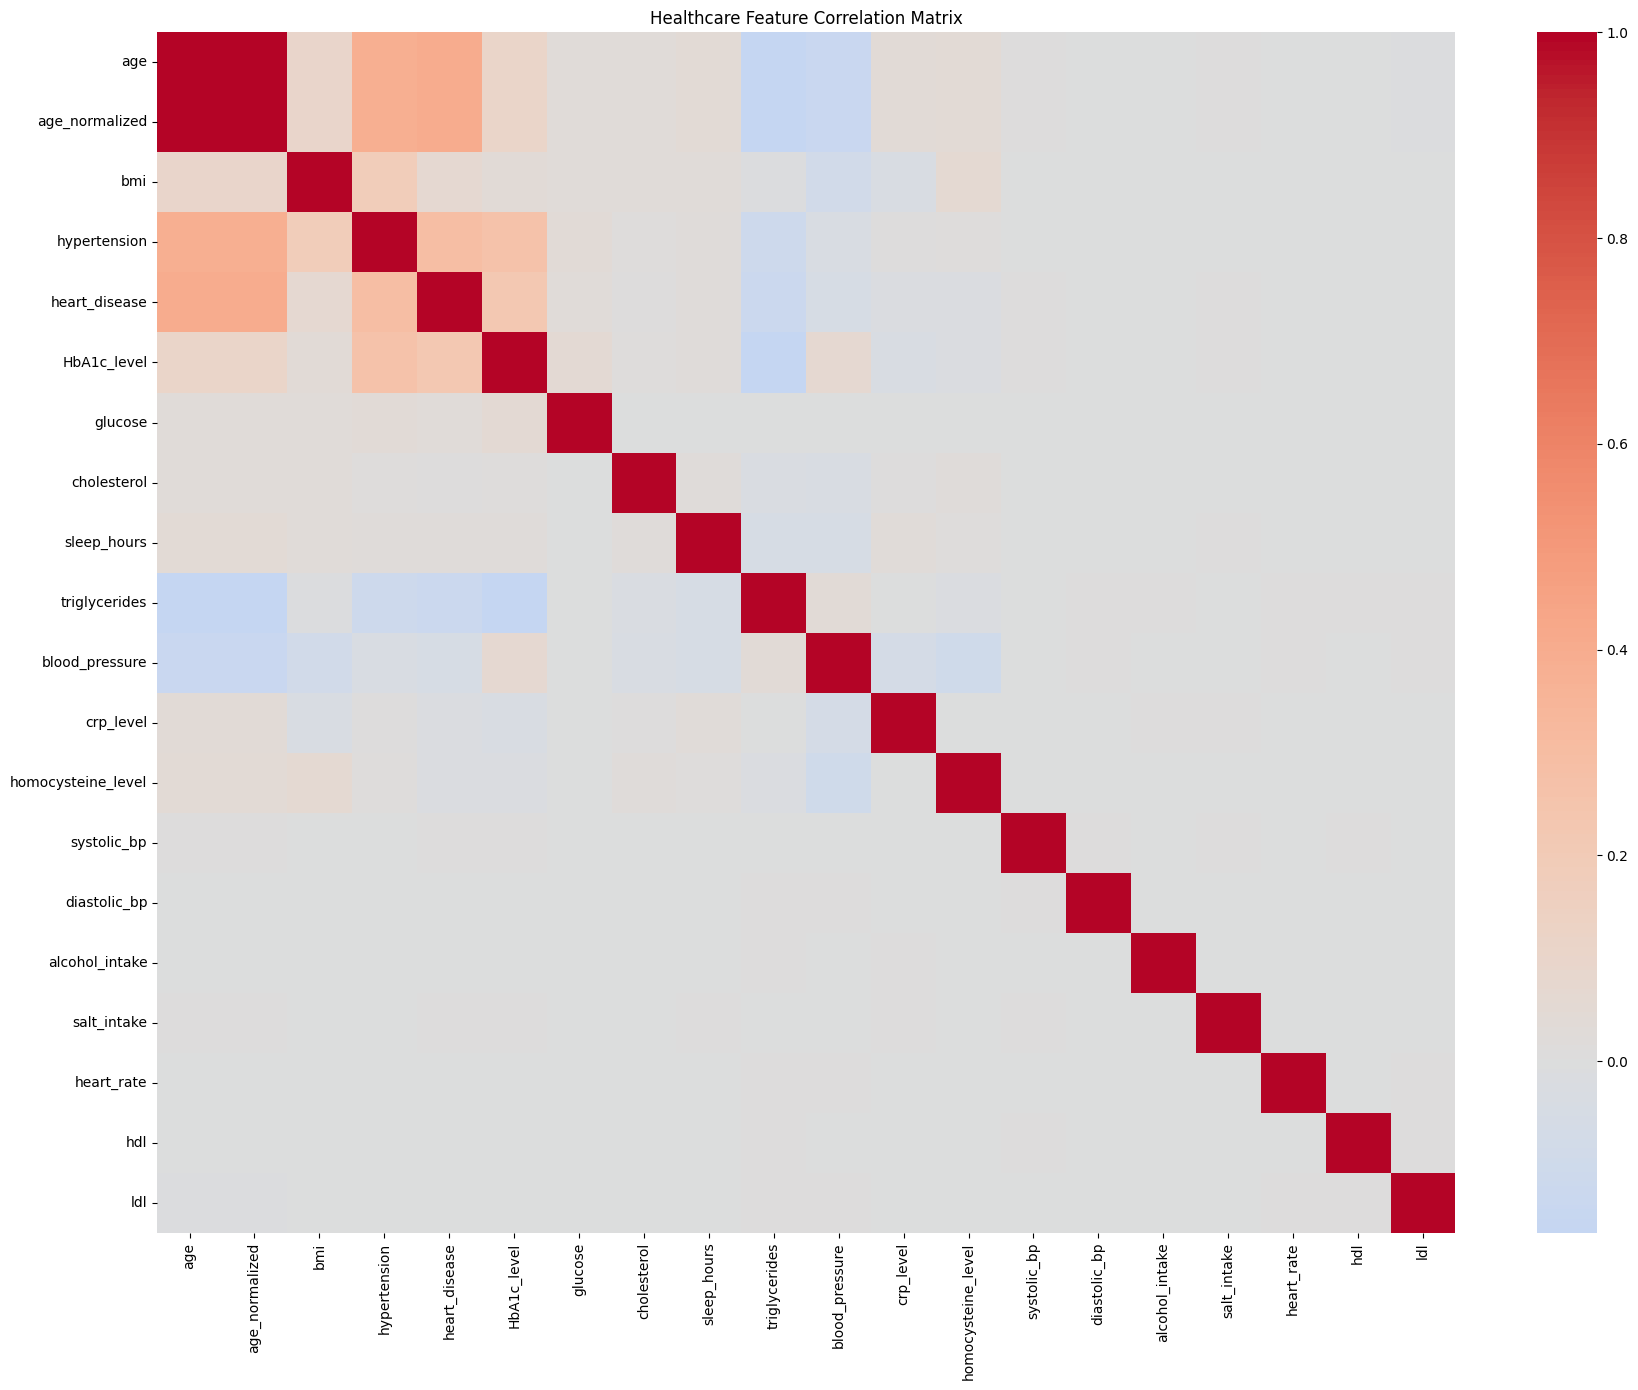

label    Abnormal     Normal
gender                      
Female  58.898382  41.101618
Male    65.406665  34.593335


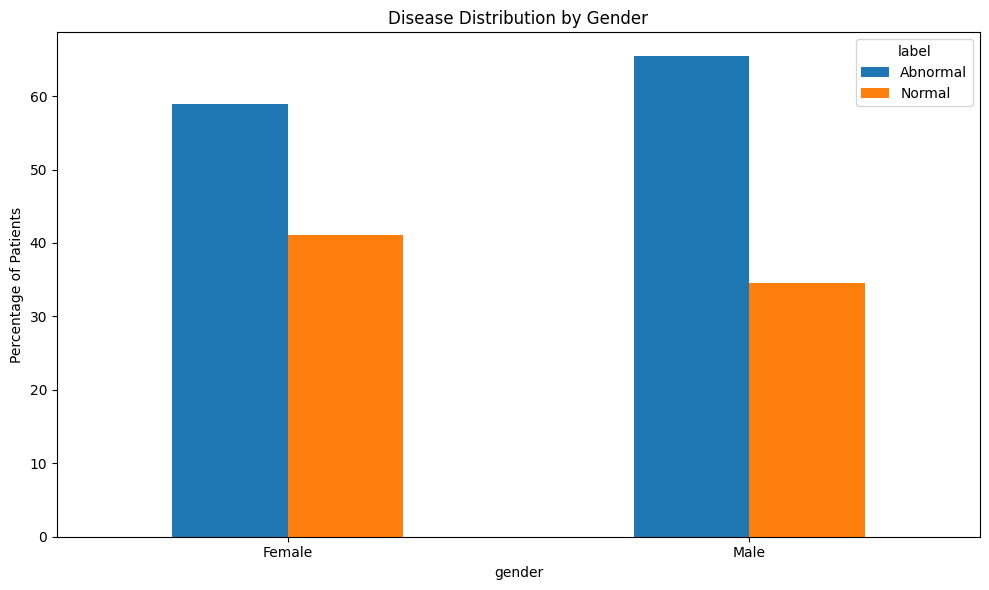

hypertension     12.821784
heart_disease     7.339048
dtype: float64


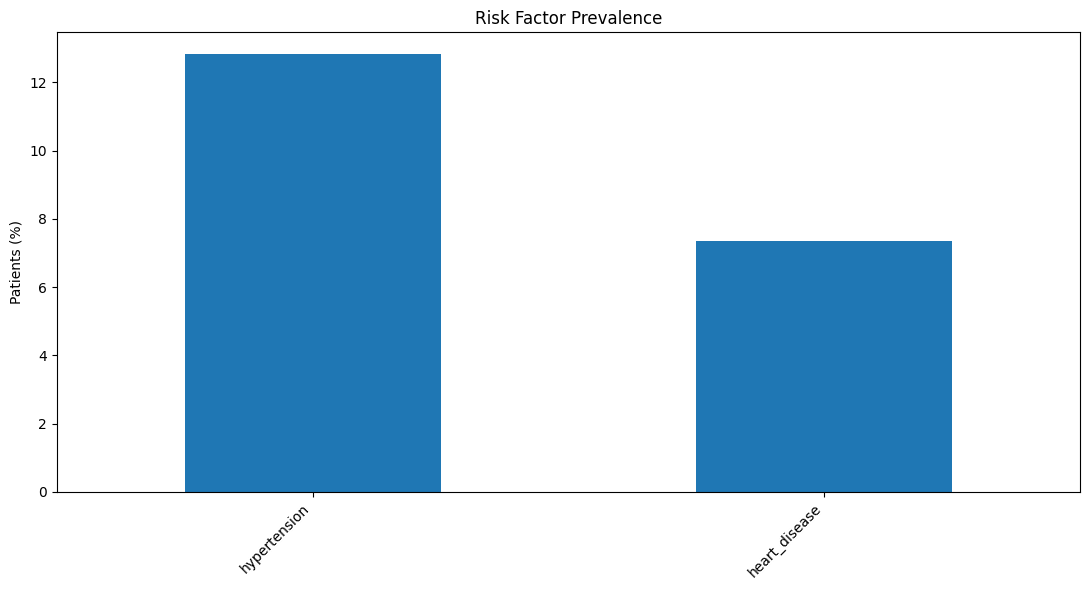

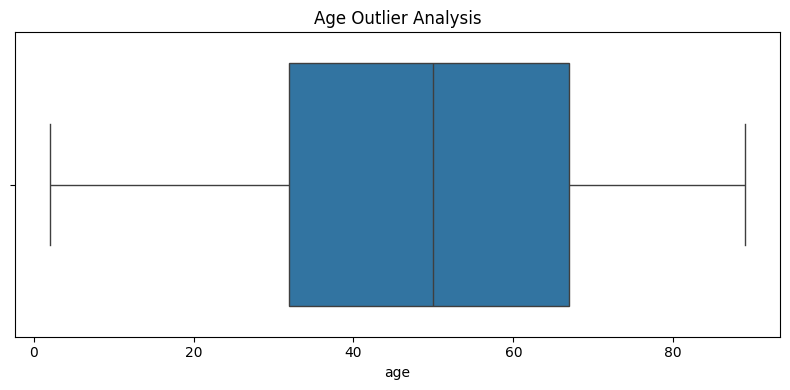

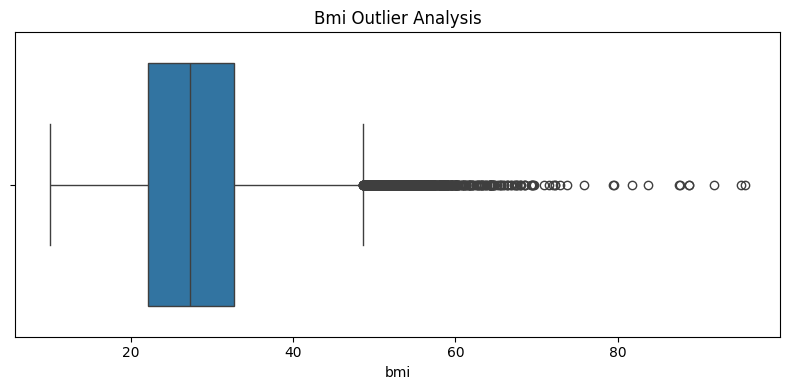

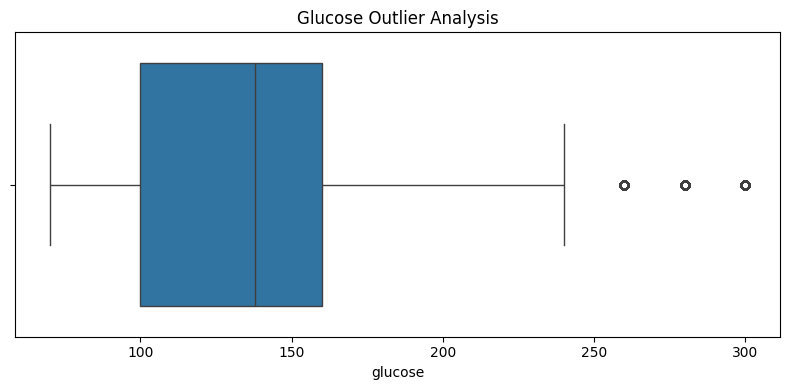

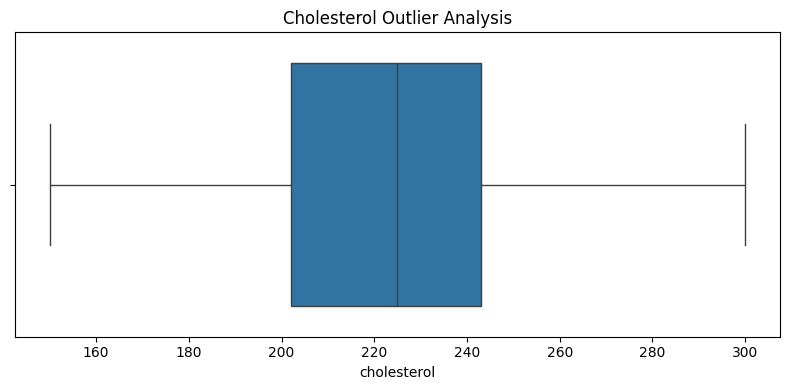

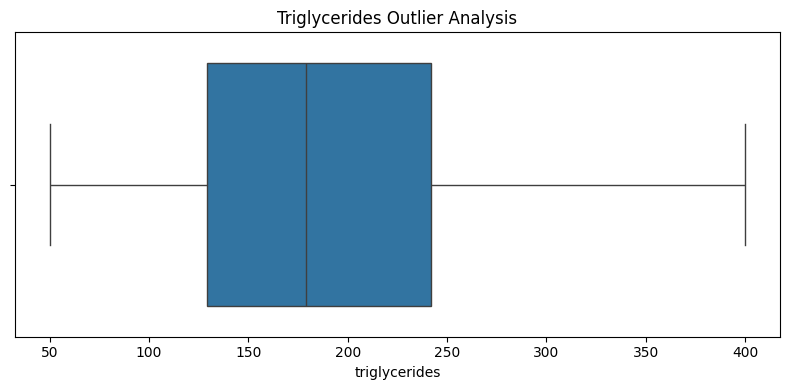

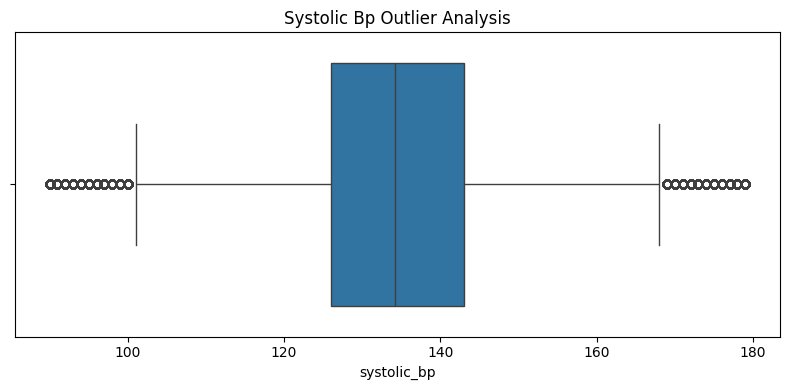

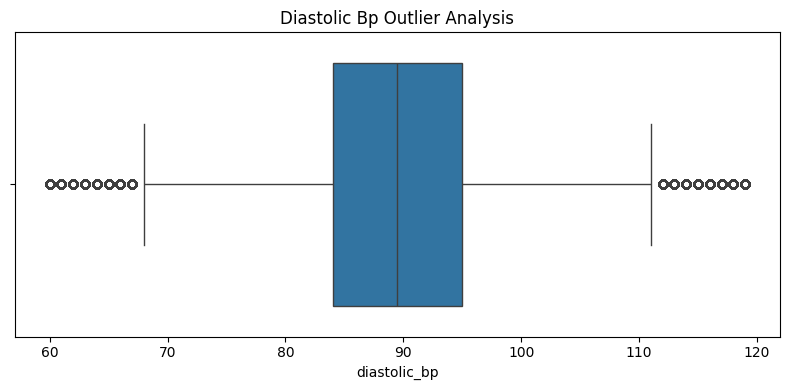

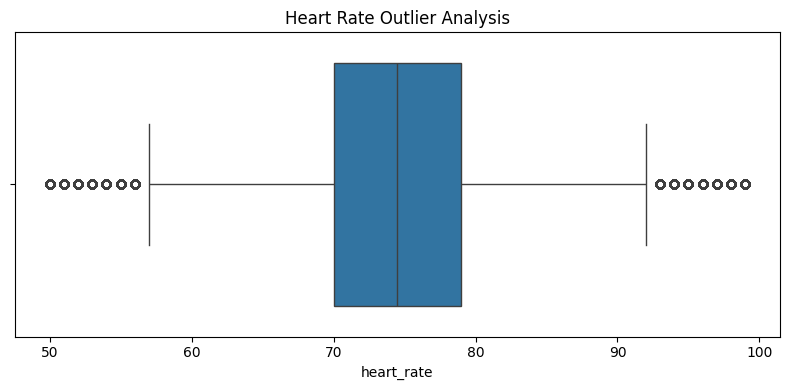

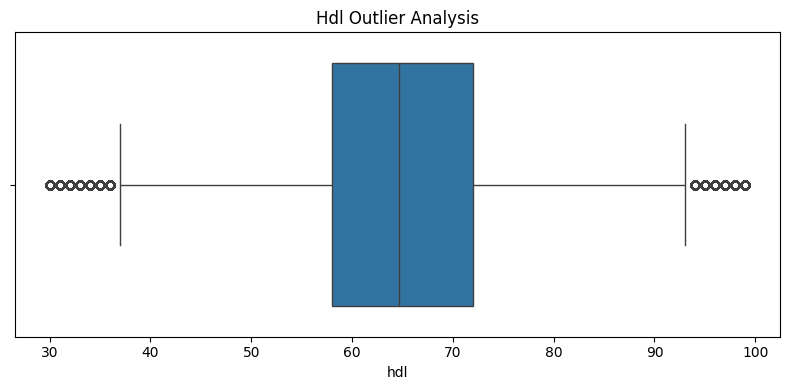

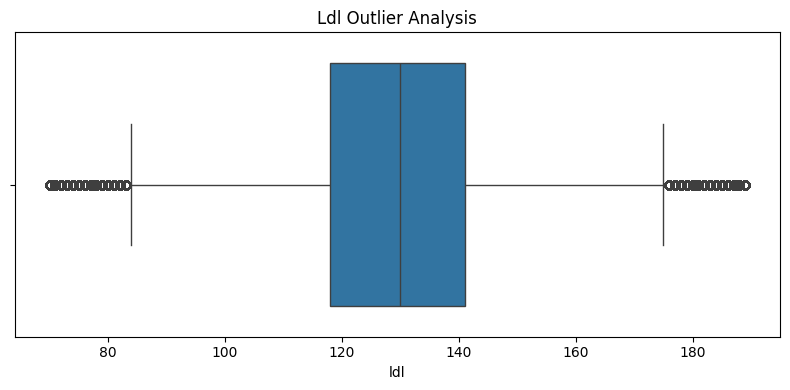

In [12]:
eda = HealthcareEDA(
    df=df,
    output_dir=project_root / "outputs/figures"
)

eda.run_all()